# Preliminary Results — First Region per Country

Gathers all `results.json` files from the first region of every country and visualises
how the once-in-100-year discharge event shifts across climate scenarios.

In [1]:
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from rich import print

## 1. Gather results

In [12]:
base_path = Path('regions')

all_results = []
for results_file in sorted(base_path.rglob('results.json')):
    country = results_file.parts[-3]   # regions/<country>/<region>/results.json
    region  = results_file.parts[-2]

    with open(results_file) as f:
        data = json.load(f)

    if 'return_periods_HBV' not in data or 'observed_reference' not in data['return_periods_HBV'] or 'catchment_area_km2' not in data:
        # print(f'[yellow]–[/yellow] {country:30s} / {region}  [dim](no return_periods_HBV)[/dim]')
        continue

    data['country'] = country
    print(f"{country = }  {region = } ")
    data['region']  = region
    all_results.append(data)

print(f'[bold]{len(all_results)} region(s) with results loaded.[/bold]')

country = 'australia'  region = 'camelsaus_104001A'

country = 'australia'  region = 'camelsaus_105102A'

country = 'australia'  region = 'camelsaus_107001B'

country = 'australia'  region = 'camelsaus_116012A'

country = 'australia'  region = 'camelsaus_136202D'

...

country = 'australia'  region = 'camelsaus_304497'

country = 'austria'  region = 'lamah_200303'

country = 'brazil'  region = 'camelsbr_25100000'

country = 'czech_republic'  region = 'lamah_328'

13 region(s) with results loaded.

## 2. Parse return-period data

In [13]:
def parse_rp(value):
    """Return (mean, std) for a return-period value (plain number or 'mean ± std' string)."""
    if isinstance(value, (int, float)):
        return float(value), 0.0
    s = str(value)
    if '\u00b1' in s:
        parts = s.split('\u00b1')
        return float(parts[0].strip()), float(parts[1].strip())
    return float(s.strip()), 0.0


def get_scenario_label(key):
    """Map a results.json key to a short display label and display order."""
    k = key.lower()
    if 'modelled discharge' in k or ('cmip' in k and 'ssp' not in k):
        return 'CMIP6\nhist', 1
    if k == 'era5':
        return 'ERA5', 2
    if 'destine' in k and ('hist' in k or 'historical' in k):
        return 'DestinE\nhist', 3
    if 'ssp126' in k:
        return 'SSP1-2.6', 4
    if 'ssp245' in k:
        return 'SSP2-4.5', 5
    if 'ssp370' in k:
        return 'SSP3-7.0', 6
    if 'ssp585' in k:
        return 'SSP5-8.5', 7
    if 'destine' in k:
        return 'DestinE\nfuture', 8
    return None, 99


# Build a tidy DataFrame: one row per (region × scenario)
rows = []
for r in all_results:
    rp_data = r['return_periods_HBV']

    # Observed reference — always 100 yr by definition
    rows.append({
        'country':        r['country'],
        'region':         r['region'],
        'caravan_id':     r['caravan_id'],
        'scenario_label': 'Observed\n(ref)',
        'order':          0,
        'rp_mean':        100.0,
        'rp_std':         0.0,
        'catchment_area_km2': r['catchment_area_km2'],
    })

    for key, vals in rp_data.items():
        if key == 'observed_reference':
            continue
        rp_val = vals.get('rp_at_obs_q100') if isinstance(vals, dict) else None
        if rp_val is None:
            continue
        label, order = get_scenario_label(key)
        if label is None:
            continue
        mean, std = parse_rp(rp_val)
        rows.append({
            'country':        r['country'],
            'region':         r['region'],
            'caravan_id':     r['caravan_id'],
            'scenario_label': label,
            'order':          order,
            'rp_mean':        mean,
            'rp_std':         std,
        })

df = pd.DataFrame(rows).sort_values(['country', 'region', 'order']).reset_index(drop=True)
print(df[['country', 'region', 'scenario_label', 'rp_mean', 'rp_std']])

country             region   scenario_label   rp_mean    rp_std
0         australia  camelsaus_104001A  Observed\n(ref)    100.00      0.00
1         australia  camelsaus_104001A      CMIP6\nhist     27.41      0.00
2         australia  camelsaus_104001A             ERA5     49.02      0.00
3         australia  camelsaus_104001A    DestinE\nhist     45.73      0.00
4         australia  camelsaus_104001A         SSP1-2.6     15.06      2.03
..              ...                ...              ...       ...       ...
112  czech_republic          lamah_328         SSP1-2.6  47037.66  17647.99
113  czech_republic          lamah_328         SSP2-4.5  78439.38  32257.19
114  czech_republic          lamah_328         SSP3-7.0  68039.88  10643.96
115  czech_republic          lamah_328         SSP5-8.5  74771.03  42135.28
116  czech_republic          lamah_328  DestinE\nfuture  66695.73      0.00

[117 rows x 5 columns]

## 3. Plot — shift of the once-in-100-year discharge

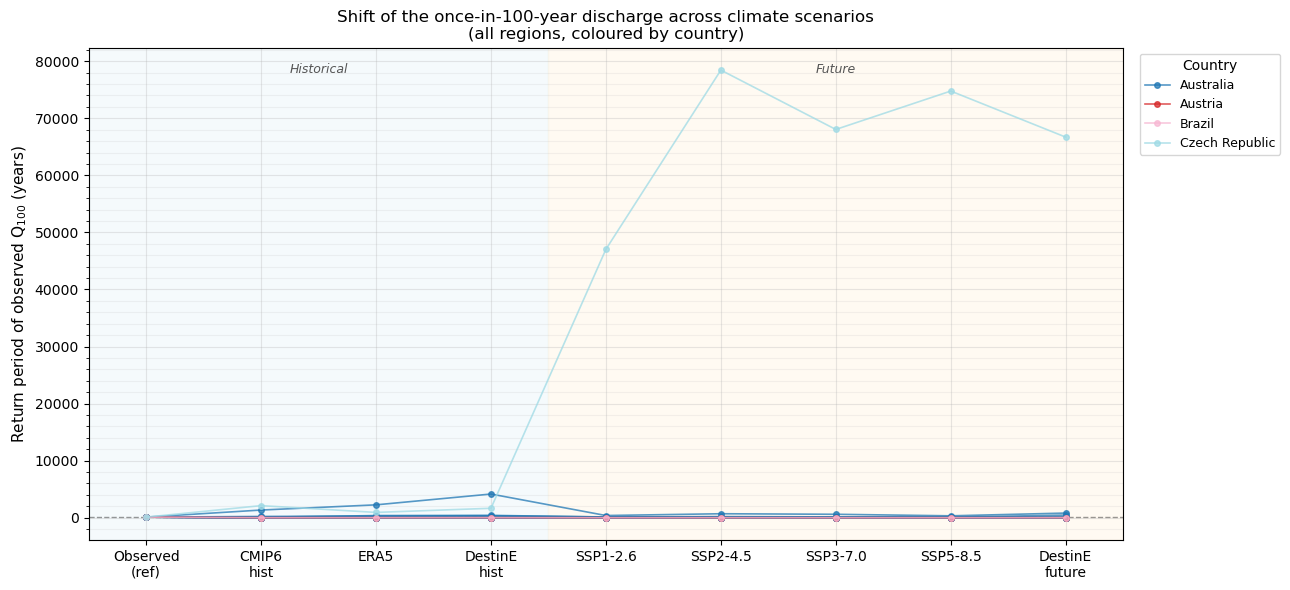

Saved: preliminary_q100_shift.png

In [14]:
ordered_labels = [
    'Observed\n(ref)',
    'CMIP6\nhist',
    'ERA5',
    'DestinE\nhist',
    'SSP1-2.6',
    'SSP2-4.5',
    'SSP3-7.0',
    'SSP5-8.5',
    'DestinE\nfuture',
]
label_to_x = {lbl: i for i, lbl in enumerate(ordered_labels)}

# One colour per country so regions of the same country share a colour
countries = sorted(df['country'].unique())
country_cmap = plt.cm.get_cmap('tab20', len(countries))
country_color = {c: country_cmap(i) for i, c in enumerate(countries)}

fig, ax = plt.subplots(figsize=(13, 6))

ax.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.4, zorder=1)
ax.axvspan(-0.5, 3.5, color='#e8f4f8', alpha=0.4, zorder=0)
ax.axvspan(3.5, len(ordered_labels) - 0.5, color='#fff3e0', alpha=0.4, zorder=0)
ax.text(1.5, 0.97, 'Historical', transform=ax.get_xaxis_transform(),
        ha='center', va='top', color='#555', fontsize=9, style='italic')
ax.text(6.0, 0.97, 'Future', transform=ax.get_xaxis_transform(),
        ha='center', va='top', color='#555', fontsize=9, style='italic')

plotted_countries = set()
for (country, region), group in df.groupby(['country', 'region'], sort=False):
    color = country_color[country]
    x_vals, y_vals = [], []
    for _, row in group.iterrows():
        lbl = row['scenario_label']
        if lbl in label_to_x:
            x_vals.append(label_to_x[lbl])
            y_vals.append(row['rp_mean'])

    ax.plot(x_vals, y_vals, 'o-', color=color, linewidth=1.2, markersize=4,
            label=country.replace('_', ' ').title() if country not in plotted_countries else '_nolegend_',
            alpha=0.75, zorder=3)
    plotted_countries.add(country)

ax.set_xticks(range(len(ordered_labels)))
ax.set_xticklabels(ordered_labels, fontsize=10)
ax.set_ylabel('Return period of observed Q$_{100}$ (years)', fontsize=11)
ax.set_title(
    'Shift of the once-in-100-year discharge across climate scenarios\n'
    '(all regions, coloured by country)',
    fontsize=12,
)
ax.set_xlim(-0.5, len(ordered_labels) - 0.5)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which='major', alpha=0.3)
ax.grid(True, which='minor', alpha=0.15)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9,
          framealpha=0.8, title='Country')

plt.tight_layout()
plt.savefig('preliminary_q100_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: preliminary_q100_shift.png')

## 4. Split by direction — wetter vs drier regions

Regions are classified by their **mean future return period** (averaged across SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5, DestinE future):

- **Wetter**: mean future RP < 100 — the Q₁₀₀ flood event becomes *more* frequent
- **Drier**: mean future RP ≥ 100 — the Q₁₀₀ flood event becomes *rarer*

Classification (based on mean future return period):

czech_republic                      → Drier   (mean future RP = 67072.0 yr)

australia                           → Wetter  (mean future RP = 78.2 yr)

austria                             → Wetter  (mean future RP = 1.2 yr)

brazil                              → Wetter  (mean future RP = 5.6 yr)

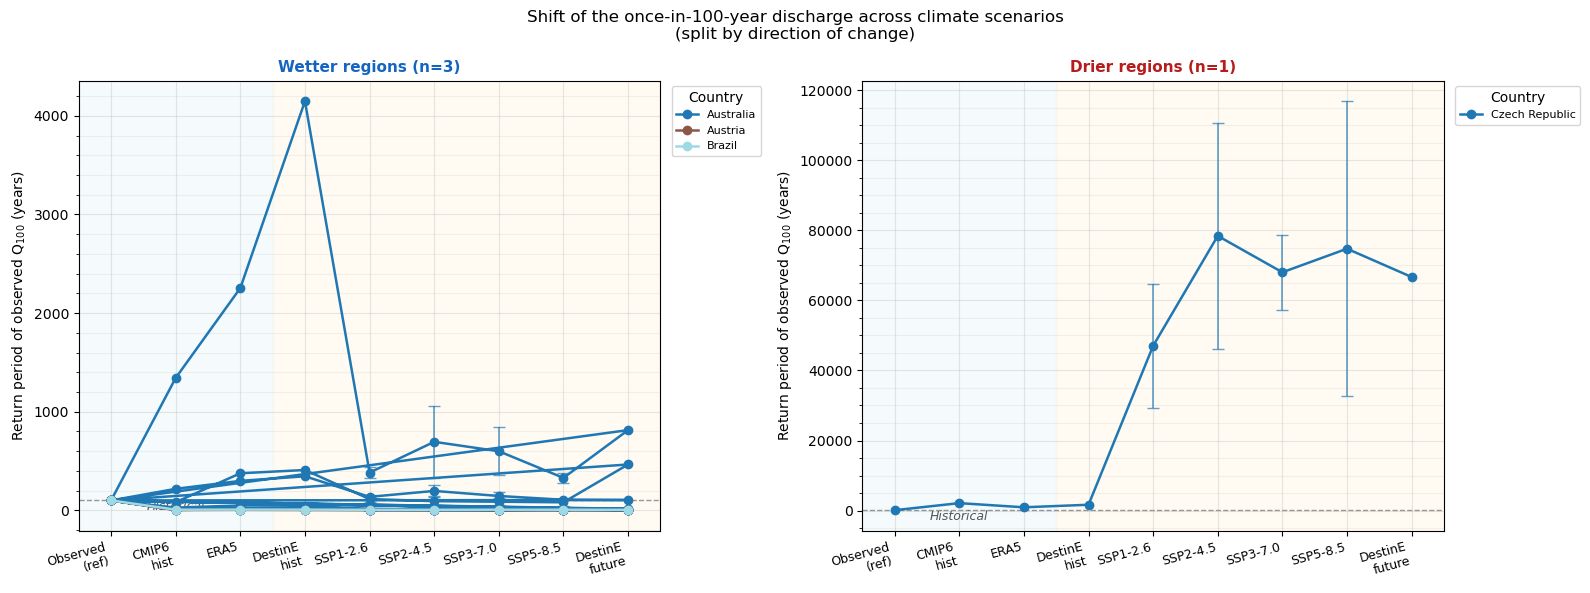

In [15]:
# Classify each region: wetter (mean future RP < 100) or drier (mean future RP >= 100)
future_scenarios = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5', 'DestinE future']
future_df = df[df['scenario_label'].isin(future_scenarios)]
mean_future_rp = future_df.groupby('country')['rp_mean'].mean()
region_class = mean_future_rp.apply(lambda x: 'Wetter' if x < 100 else 'Drier')

print("Classification (based on mean future return period):")
for country, direction in region_class.sort_values().items():
    rp = mean_future_rp[country]
    print(f"  {country:35s} → {direction:6s}  (mean future RP = {rp:.1f} yr)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle(
    'Shift of the once-in-100-year discharge across climate scenarios\n'
    '(split by direction of change)',
    fontsize=12,
)

plot_labels = ordered_labels

for ax, direction in zip(axes, ['Wetter', 'Drier']):
    group_countries = region_class[region_class == direction].index
    group_df = df[df['country'].isin(group_countries)]

    # Colour palette for this panel
    n = len(group_countries)
    cmap = plt.cm.get_cmap('tab20', max(n, 1))
    color_map = {c: cmap(i) for i, c in enumerate(sorted(group_countries))}

    # Reference line
    ax.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.4, zorder=1)

    # Shaded background: historical / future
    ax.axvspan(-0.5, 2.5, color='#e8f4f8', alpha=0.4, zorder=0)
    ax.axvspan(2.5, len(plot_labels) - 0.5, color='#fff3e0', alpha=0.4, zorder=0)
    ax.text(1.0, ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else 200,
            'Historical', ha='center', va='top', color='#555', fontsize=9, style='italic')

    for country, grp in group_df.groupby('country'):
        color = color_map[country]
        x_vals, y_vals, y_errs = [], [], []
        for _, row in grp.iterrows():
            lbl = row['scenario_label']
            if lbl in label_to_x:
                x_vals.append(label_to_x[lbl])
                y_vals.append(row['rp_mean'])
                y_errs.append(row['rp_std'])

        ax.plot(x_vals, y_vals, 'o-', color=color, linewidth=1.8,
                markersize=6, label=country.replace('_', ' ').title(), zorder=3)
        for x, y, ye in zip(x_vals, y_vals, y_errs):
            if ye > 0:
                ax.errorbar(x, y, yerr=ye, fmt='none', ecolor=color,
                            elinewidth=1.2, capsize=4, alpha=0.7, zorder=2)

    title_color = '#1565C0' if direction == 'Wetter' else '#B71C1C'
    ax.set_title(f'{direction} regions (n={n})', fontsize=11, color=title_color, fontweight='bold')
    ax.set_xticks(range(len(plot_labels)))
    ax.set_xticklabels(plot_labels, fontsize=9, rotation=15, ha='right')
    ax.set_ylabel('Return period of observed Q$_{100}$ (years)', fontsize=10)
    ax.set_xlim(-0.5, len(plot_labels) - 0.5)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(True, which='major', alpha=0.3)
    ax.grid(True, which='minor', alpha=0.15)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8,
              framealpha=0.8, title='Country')

plt.tight_layout()
# plt.savefig('preliminary_q100_split.png', dpi=150, bbox_inches='tight')
plt.show()
# print('Saved: preliminary_q100_split.png')

## 5. Summary table

In [16]:
pivot = df.pivot_table(
    index='country',
    columns='scenario_label',
    values='rp_mean',
    aggfunc='first',
)

# Reorder columns
present_cols = [c for c in ordered_labels if c in pivot.columns]
pivot = pivot[present_cols]
pivot.index = pivot.index.str.replace('_', ' ').str.title()

# 'Observed (ref)' is Q100 discharge in mm/d; all other columns are return periods in years
fmt = {c: '{:.1f}' for c in present_cols if c != 'Observed (ref)'}
if 'Observed (ref)' in present_cols:
    fmt['Observed (ref)'] = '{:.4f}'
rp_cols = [c for c in present_cols if c != 'Observed (ref)']

pivot.style \
    .format(fmt) \
    .background_gradient(cmap='RdYlGn_r', subset=rp_cols, axis=None, vmin=50, vmax=200) \
    .set_caption(
        'Observed (ref): Q\u2081\u2080\u2080 reference discharge (mm/d) — '
        'all other columns: return period (years) of that discharge under each scenario '
        '(> 100 \u2192 event becomes rarer; < 100 \u2192 more frequent)'
    )

scenario_label,Observed (ref),CMIP6 hist,ERA5,DestinE hist,SSP1-2.6,SSP2-4.5,SSP3-7.0,SSP5-8.5,DestinE future
country,,,,,,,,,
Australia,100.0,27.4,49.0,45.7,15.1,11.8,13.5,13.6,15.2
Austria,100.0,2.3,4.0,2.5,1.3,1.2,1.2,1.3,1.3
Brazil,100.0,6.1,7.2,6.7,5.2,5.3,6.2,6.0,5.0
Czech Republic,100.0,2113.3,927.3,1651.7,47037.7,78439.4,68039.9,74771.0,66695.7


## 6. Q₁₀₀ reference discharge in m³/s

Converts the observed Q₁₀₀ reference from mm/d to m³/s using the catchment area:

**Q (m³/s) = Q (mm/d) × Area (km²) / 86.4**

In [17]:
# Build country → catchment area lookup from the loaded results
area_lookup = {r['country']: r['catchment_area_km2'] for r in all_results}

# Pull the observed-reference rows (q100_mm_d stored in rp_mean)
ref_table = (
    df[df['scenario_label'] == 'Observed (ref)'][['country', 'rp_mean']]
    .copy()
    .rename(columns={'rp_mean': 'q100_mm_d'})
)
ref_table['catchment_area_km2'] = ref_table['country'].map(area_lookup)
# Conversion: mm/d × km² / 86.4 = m³/s
ref_table['q100_m3s'] = ref_table['q100_mm_d'] * ref_table['catchment_area_km2'] / 86.4
ref_table['country'] = ref_table['country'].str.replace('_', ' ').str.title()
ref_table = ref_table.set_index('country')

ref_table[['catchment_area_km2', 'q100_mm_d', 'q100_m3s']].rename(columns={
    'catchment_area_km2': 'Area (km²)',
    'q100_mm_d':          'Q₁₀₀ (mm/d)',
    'q100_m3s':           'Q₁₀₀ (m³/s)',
}).style \
    .format({'Area (km²)': '{:.0f}', 'Q₁₀₀ (mm/d)': '{:.4f}', 'Q₁₀₀ (m³/s)': '{:.2f}'}) \
    .background_gradient(cmap='Blues', subset=['Q₁₀₀ (m³/s)'], axis=0) \
    .set_caption('Observed Q₁₀₀ reference discharge per region')

,Area (km²),Q₁₀₀ (mm/d),Q₁₀₀ (m³/s)
country,,,
